In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Display the first 10 rows.
df = pd.read_csv('day.csv')
df.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
5,6,06-01-2018,1,0,1,0,4,1,1,8.378268,11.66045,51.8261,6.000868,88,1518,1606
6,7,07-01-2018,1,0,1,0,5,1,2,8.057402,10.44195,49.8696,11.304642,148,1362,1510
7,8,08-01-2018,1,0,1,0,6,0,2,6.765000,8.11270,53.5833,17.875868,68,891,959
8,9,09-01-2018,1,0,1,0,0,0,1,5.671653,5.80875,43.4167,24.250650,54,768,822
9,10,10-01-2018,1,0,1,0,1,1,1,6.184153,7.54440,48.2917,14.958889,41,1280,1321


In [3]:
#Check dataset shape.
df.shape

(730, 16)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,730.0,365.500000,210.877136,1.000000,183.250000,365.500000,547.750000,730.000000
season,730.0,2.498630,1.110184,1.000000,2.000000,3.000000,3.000000,4.000000
yr,730.0,0.500000,0.500343,0.000000,0.000000,0.500000,1.000000,1.000000
mnth,730.0,6.526027,3.450215,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,730.0,0.028767,0.167266,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,730.0,2.997260,2.006161,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,730.0,0.683562,0.465405,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,730.0,1.394521,0.544807,1.000000,1.000000,1.000000,2.000000,3.000000
temp,730.0,20.319259,7.506729,2.424346,13.811885,20.465826,26.880615,35.328347
atemp,730.0,23.726322,8.150308,3.953480,16.889713,24.368225,30.445775,42.044800


In [5]:
#Identify numerical vs categorical columns.
categorical_columns=df.select_dtypes(include=['object']).columns
numerical_columns=df.select_dtypes(include=['int64','float64']).columns
print(f'Categorical Columns: {categorical_columns}')
print()
print(f'Numerical Columns: {numerical_columns}')


Categorical Columns: Index(['dteday'], dtype='object')

Numerical Columns: Index(['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='object')


In [6]:
#Convert date column to datetime.
df['dteday']=pd.to_datetime(df['dteday'], errors='coerce')

In [7]:
#Check missing values.
df.isnull().sum()

instant         0
dteday        442
season          0
yr              0
mnth            0
holiday         0
weekday         0
workingday      0
weathersit      0
temp            0
atemp           0
hum             0
windspeed       0
casual          0
registered      0
cnt             0
dtype: int64

In [8]:
df['dteday']=df['dteday'].fillna(df['dteday'].mode()[0])

In [9]:
df['mnth'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [10]:
df['workingday'].unique()

array([0, 1])

In [11]:
df['yr'].unique()

array([0, 1])

<Axes: xlabel='cnt', ylabel='Count'>

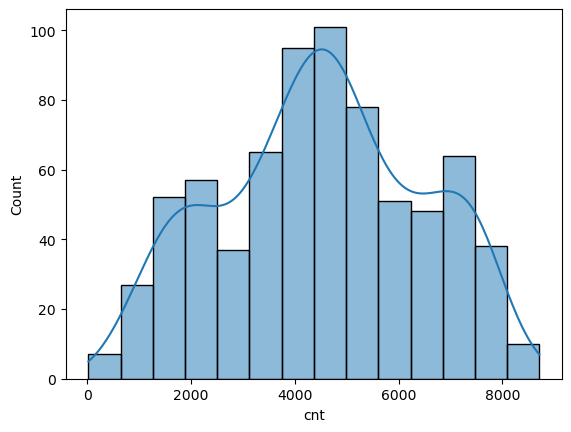

In [12]:
#Plot distribution of total bike rentals (cnt).
sns.histplot(df, x='cnt', kde=True)

In [13]:
#Calculate average daily rentals.
df['cnt'].mean()

np.float64(4508.006849315068)

In [14]:
#Find highest and lowest rental days.
rental_day=df.groupby('dteday')['cnt'].sum()
print(f'The highest rental day is: {rental_day.max()}')
print(f'The lowest rental day is: {rental_day.min()}')


The highest rental day is: 1992801
The lowest rental day is: 605


In [15]:
#Calculate average rentals by season.
df.groupby('season')['cnt'].mean().sort_values(ascending=False)

season
3    5644.303191
2    4992.331522
4    4728.162921
1    2608.411111
Name: cnt, dtype: float64

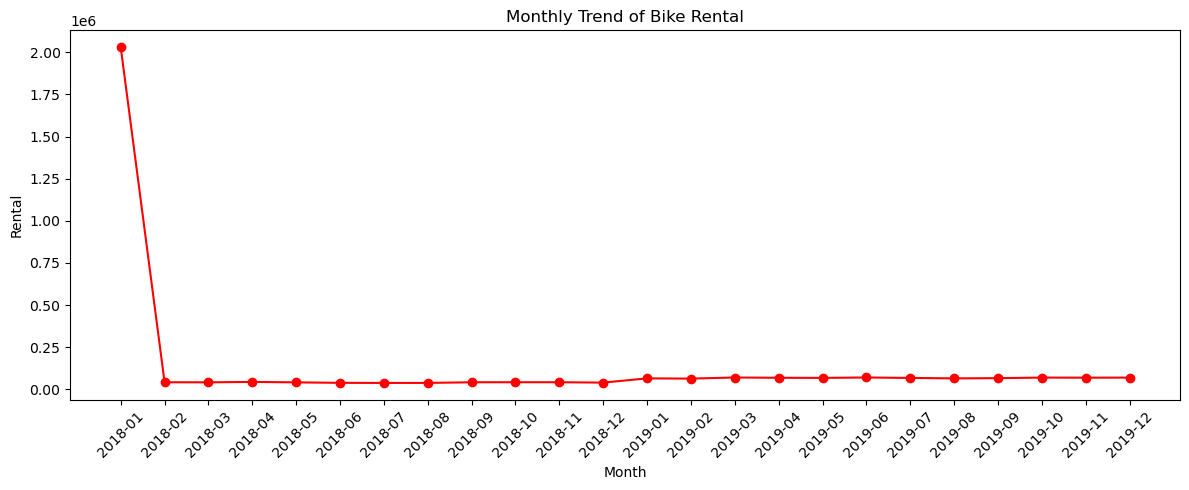

In [16]:
#Plot rentals by month.
plt.figure(figsize=(12,5))
monthly_rental=df.groupby(df['dteday'].dt.to_period('M'))['cnt'].sum()
monthly_rental.index=monthly_rental.index.astype(str)
plt.plot(monthly_rental.index, monthly_rental.values, marker='o', color='red')
plt.title('Monthly Trend of Bike Rental')
plt.xlabel('Month')
plt.ylabel('Rental')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

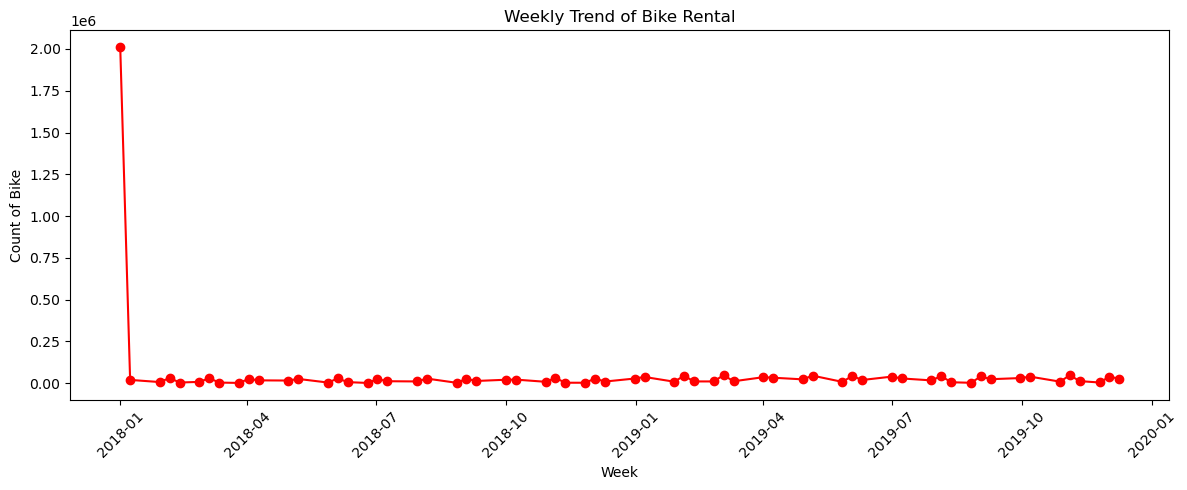

In [17]:
#Plot rentals by weekday.
plt.figure(figsize=(12,5))
weekly_rental=df.groupby(df['dteday'].dt.to_period('W'))['cnt'].sum()
weekly_rental.index = weekly_rental.index.to_timestamp()
plt.plot(weekly_rental.index, weekly_rental.values, marker='o', color='red')
plt.title('Weekly Trend of Bike Rental')
plt.xlabel('Week')
plt.ylabel('Count of Bike')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
#Question:
#Which season has the highest demand?

In [19]:
#Compare rentals by weather condition.
df.groupby('weathersit')['cnt'].sum()

weathersit
1    2257952
2     995024
3      37869
Name: cnt, dtype: int64

In [20]:
#Analyze temperature vs rentals.
df.groupby('temp')['cnt'].mean().sort_values(ascending=False)

temp
24.668347    8362.0
24.600000    8294.0
25.010000    8227.0
25.966653    8009.0
21.695847    7907.0
              ...  
8.883347      683.0
15.952731     623.0
15.437402     605.0
7.995000      431.0
18.040000      22.0
Name: cnt, Length: 498, dtype: float64

In [21]:
#Analyze humidity vs rentals.
df.groupby('hum')['cnt'].mean().sort_values(ascending=False)

hum
50.1667    8714.0
54.2917    8555.0
62.7500    8156.0
57.2917    8090.0
67.2500    8009.0
            ...  
88.2500     627.0
0.0000      623.0
94.8261     605.0
68.7500     431.0
88.0000      22.0
Name: cnt, Length: 594, dtype: float64

In [22]:
#Question:
#Does bad weather reduce rentals?

In [23]:
#Compare casual vs registered users.
df[['casual', 'registered', 'cnt']].describe()

,casual,registered,cnt
count,730.000000,730.000000,730.000000
mean,849.249315,3658.757534,4508.006849
std,686.479875,1559.758728,1936.011647
min,2.000000,20.000000,22.000000
25%,316.250000,2502.250000,3169.750000
50%,717.000000,3664.500000,4548.500000
75%,1096.500000,4783.250000,5966.000000
max,3410.000000,6946.000000,8714.000000


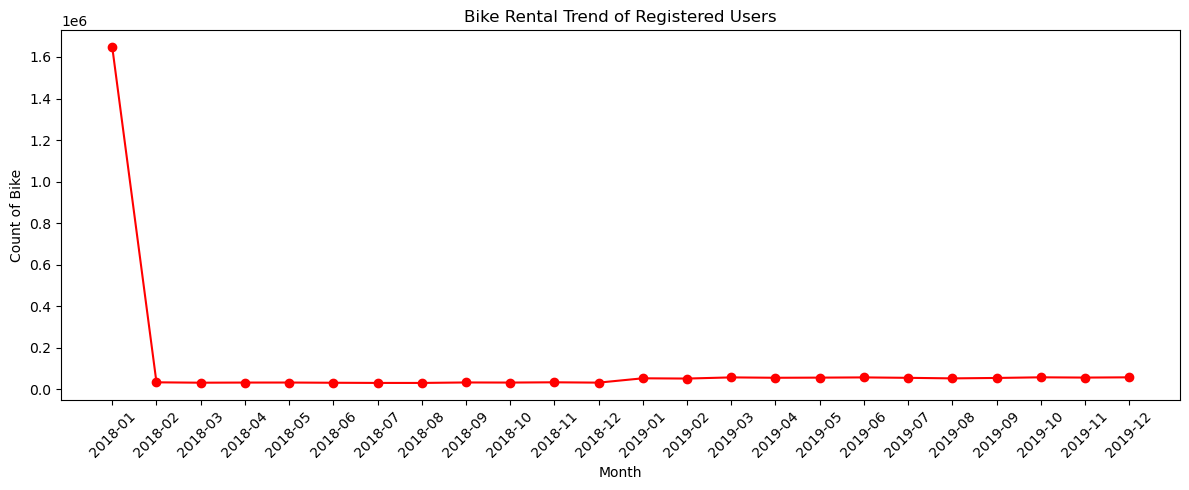

In [24]:
#Plot trend of registered users over time.
plt.figure(figsize=(12,5))
reg_rental=df.groupby(df['dteday'].dt.to_period('M'))['registered'].sum()
reg_rental.index=reg_rental.index.astype(str)
plt.plot(reg_rental.index, reg_rental.values, marker='o', color='red')
plt.title('Bike Rental Trend of Registered Users')
plt.xlabel('Month')
plt.ylabel('Count of Bike')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
#Question:
#Do registered users dominate demand?

In [26]:
#Extract:year,month,day
df['year']=df['dteday'].dt.year
df['month']=df['dteday'].dt.month
df['day']=df['dteday'].dt.day

In [27]:
#Create temperature categories:Cold,Mild,Hot
bins=[0,14,24,float('inf')]
labels=['Cold','Mild','Hot']
df['temp_group']=pd.cut(df['temp'], bins=bins, labels=labels, right=False)
df[['temp', 'temp_group']].head()

,temp,temp_group
0,14.110847,Mild
1,14.902598,Mild
2,8.050924,Cold
3,8.200000,Cold
4,9.305237,Cold


In [28]:
df['temp_group'].value_counts()

temp_group
Mild    275
Hot     269
Cold    186
Name: count, dtype: int64

In [29]:
#Create wind speed categories.
bins=[0,11,27,float('inf')]
labels=['low','mid','high']
df['wind_group']=pd.cut(df['windspeed'], bins=bins, labels=labels)
df[['windspeed', 'wind_group']].head()

,windspeed,wind_group
0,10.749882,low
1,16.652113,mid
2,16.636703,mid
3,10.739832,low
4,12.522300,mid


In [30]:
df['wind_group'].value_counts()

wind_group
mid     425
low     296
high      9
Name: count, dtype: int64

In [31]:
#Create a feature: casual_ratio = casual / cnt
df['casual_ratio']=(df['casual'] / df['cnt'])

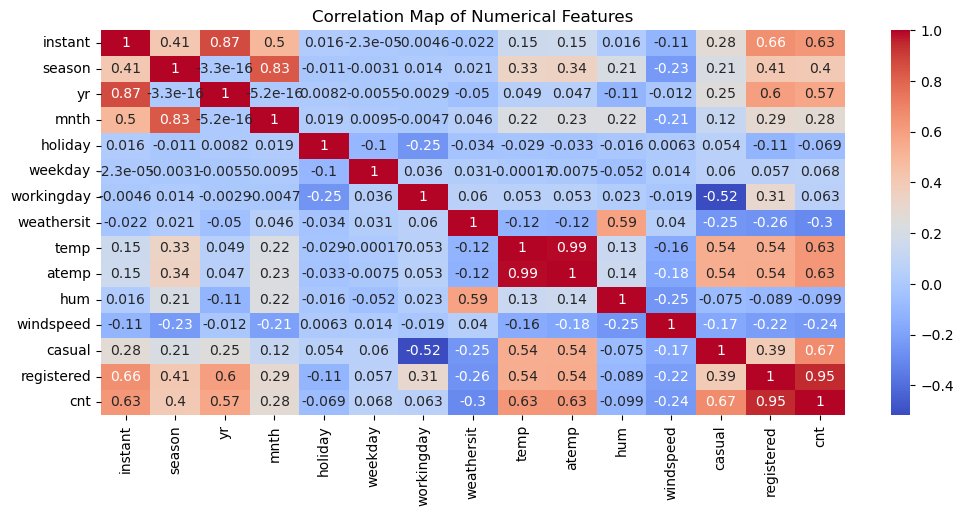

In [32]:
#Create a correlation heatmap.
plt.figure(figsize=(12,5))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Map of Numerical Features')
plt.show()

In [33]:
#Identify top variables influencing rentals
corr = df.corr(numeric_only=True)['cnt'].drop('cnt').sort_values(ascending=False)
print(corr)

registered      0.945411
casual          0.672123
atemp           0.630685
instant         0.629896
temp            0.627044
yr              0.569728
season          0.404584
year            0.289722
mnth            0.278191
casual_ratio    0.273688
day             0.168212
weekday         0.067534
workingday      0.062542
month           0.007998
holiday        -0.068764
hum            -0.098543
windspeed      -0.235132
weathersit     -0.295929
Name: cnt, dtype: float64


In [34]:
x=df[['atemp','temp','yr','month','season','casual_ratio','weekday','workingday','hum','windspeed']]
y=df['cnt']

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler
sca=StandardScaler()
x_train_scaled=sca.fit_transform(x_train)
x_test_scaled=sca.fit_transform(x_test)

In [37]:
#Linear Regression
from sklearn.linear_model import LinearRegression
lreg=LinearRegression()
lreg.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
lreg.intercept_

np.float64(4546.361301369863)

In [39]:
lreg.coef_

array([ 893.13253759, -125.57940561, 1033.57986626,   67.07805534,
        466.68537604,  571.52169907,  115.71066371,  514.65627835,
       -301.74512606, -196.0293245 ])

In [40]:
yhat_lreg_train=lreg.predict(x_train_scaled)
yhat_lreg_test=lreg.predict(x_test_scaled)

In [41]:
comparison=pd.DataFrame({'Actual':y_test.squeeze(), 'Predicted':yhat_lreg_test})
comparison.head()

,Actual,Predicted
468,7460,6316.908270
148,4788,4317.613969
302,3331,3156.661006
355,3068,2813.489846
515,7338,6865.784626


In [42]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [43]:
r2_lreg=r2_score(y_test, yhat_lreg_test)
print(f'R-Squared score: {r2_lreg:.4f}')

R-Squared score: 0.8402


In [44]:
mse_lreg=mean_squared_error(y_test, yhat_lreg_test)
rmse_lreg=np.sqrt(mse_lreg)
print(f'Mean Squared Error(MSE): {mse_lreg:.4f}')
print(f'Root Mean Squared Error(RMSE): {rmse_lreg:.4f}')

Mean Squared Error(MSE): 547045.3699
Root Mean Squared Error(RMSE): 739.6252


In [45]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
tree=DecisionTreeRegressor()
tree.fit(x_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [46]:
yhat_tree_train=tree.predict(x_train_scaled)
yhat_tree_test=tree.predict(x_test_scaled)

In [47]:
r2_tree=r2_score(y_test, yhat_tree_test)
print(f'R-Squared score: {r2_tree:.4f}')

R-Squared score: 0.7648


In [48]:
mse_tree=mean_squared_error(y_test, yhat_tree_test)
rmse_tree=np.sqrt(mse_tree)
print(f'Mean Squared Error(MSE): {mse_tree:.4f}')
print(f'Root Mean Squared Error(RMSE): {rmse_tree:.4f}')

Mean Squared Error(MSE): 804953.3356
Root Mean Squared Error(RMSE): 897.1919


In [49]:
from sklearn.linear_model import PoissonRegressor

# Use this instead of LinearRegression()
model = PoissonRegressor()
model.fit(x_train_scaled, y_train)
preds = model.predict(x_test_scaled) # These will all be > 0


In [50]:
# Create a comparison table
comparison = pd.DataFrame({
    'Actual': y_test, 
    'Predicted': preds
})

# Show the first 10 rows
print(comparison.head(10))


     Actual    Predicted
468    7460  6304.855986
148    4788  4182.162557
302    3331  3142.820331
355    3068  2749.048202
515    7338  7044.522447
266    5423  4329.937796
72     2046  3005.586175
81     2121  2488.046622
133    3409  2827.660589
342    3620  3706.092390


In [51]:
score = r2_score(y_test, preds)
print(f"R2 Score: {score:.4f}")

R2 Score: 0.8041


In [52]:
# Example: [atemp, temp, yr, month, season, weekday, workingday, casual_ratio, hum, windspeed]
# Fill these in with your own test values
custom_input = [[15.2, 18.1, 1, 5, 2, 3, 1, 0.25, 60.5, 12.5]]

# Predict
single_pred = model.predict(custom_input)

print(f"Predicted Count: {single_pred[0]}")


Predicted Count: 1447.3348865110993


In [70]:
custom_input = [[15.2, 18.1, 1, 5, 2, 3, 1, 0.25, 60.5, 12.5]]

# Predict
single_pred = lreg.predict(custom_input)

print(f"Predicted Count: {single_pred[0]}")

Predicted Count: -595.6773260985265


In [53]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rfc=RandomForestRegressor()
rfc.fit(x_train_scaled, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
yhat_rfc_train=rfc.predict(x_train_scaled)
yhat_rfc_test=rfc.predict(x_test_scaled)

In [55]:
r2_rfc=r2_score(y_test, yhat_rfc_test)
print(f'R-Squared Score: {r2_rfc:.4f}')

R-Squared Score: 0.9004


In [56]:
mse_rfc=mean_squared_error(y_test, yhat_rfc_test)
rmse_rfc=np.sqrt(mse_rfc)
print(f'Mean Squared Error(MSE): {mse_rfc:.4f}')
print(f'Root Mean Squared Error(RMSE): {rmse_rfc:.4f}')

Mean Squared Error(MSE): 340854.2551
Root Mean Squared Error(RMSE): 583.8272


In [57]:
#Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
gbr.fit(x_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [58]:
yhat_gbr_train=gbr.predict(x_train_scaled)
yhat_gbr_test=gbr.predict(x_test_scaled)

In [59]:
r2_gbr=r2_score(y_test, yhat_gbr_test)
print(f'R-Squared Score: {r2_gbr:.4f}')

R-Squared Score: 0.8979


In [60]:
mse_gbr=mean_squared_error(y_test, yhat_gbr_test)
rmse_gbr=np.sqrt(mse_gbr)
print(f'Mean Squared Error(MSE): {mse_gbr:.4f}')
print(f'Root Mean Squared Error(RMSE): {rmse_gbr:.4f}')

Mean Squared Error(MSE): 349498.1403
Root Mean Squared Error(RMSE): 591.1837


In [65]:
x_data=pd.DataFrame({
    'atemp':[5.9628],
    'temp':[7.567000],
    'yr':[1],
    'month':[7],
    'season':[3],
    'casual_ratio':[0.13750556],
    'weekday':[4],
    'workingday':[1],
    'hum':[43.6957],
    'windspeed':[24.250650]
})
x_data.head()

,atemp,temp,yr,month,season,casual_ratio,weekday,workingday,hum,windspeed
0,5.9628,7.567,1,7,3,0.137506,4,1,43.6957,24.25065


In [69]:
x_data.pred=lreg.predict(x_data).round(1)

ValueError: X has 11 features, but LinearRegression is expecting 10 features as input.

In [67]:
x_data['cnt']=x_data.pred

In [68]:
x_data.head()

,atemp,temp,yr,month,season,casual_ratio,weekday,workingday,hum,windspeed,cnt
0,5.9628,7.567,1,7,3,0.137506,4,1,43.6957,24.25065,-5057.9
